<a href="https://colab.research.google.com/github/Vanshu2374/ML-projects/blob/main/projects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print("hello")

hello


Bike Project

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32648 entries, 0 to 32647
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   bike_name   32648 non-null  object 
 1   price       32648 non-null  float64
 2   city        32648 non-null  object 
 3   kms_driven  32648 non-null  float64
 4   owner       32648 non-null  object 
 5   age         32648 non-null  float64
 6   power       32648 non-null  float64
 7   brand       32648 non-null  object 
dtypes: float64(4), object(4)
memory usage: 2.0+ MB
maximum price of ktm bike :- 860000.0
Total no. of unique bike of hero :- 74
Total no. of cd delux unique bik :- 706
minimum price of cd delux bike :- 10000.0


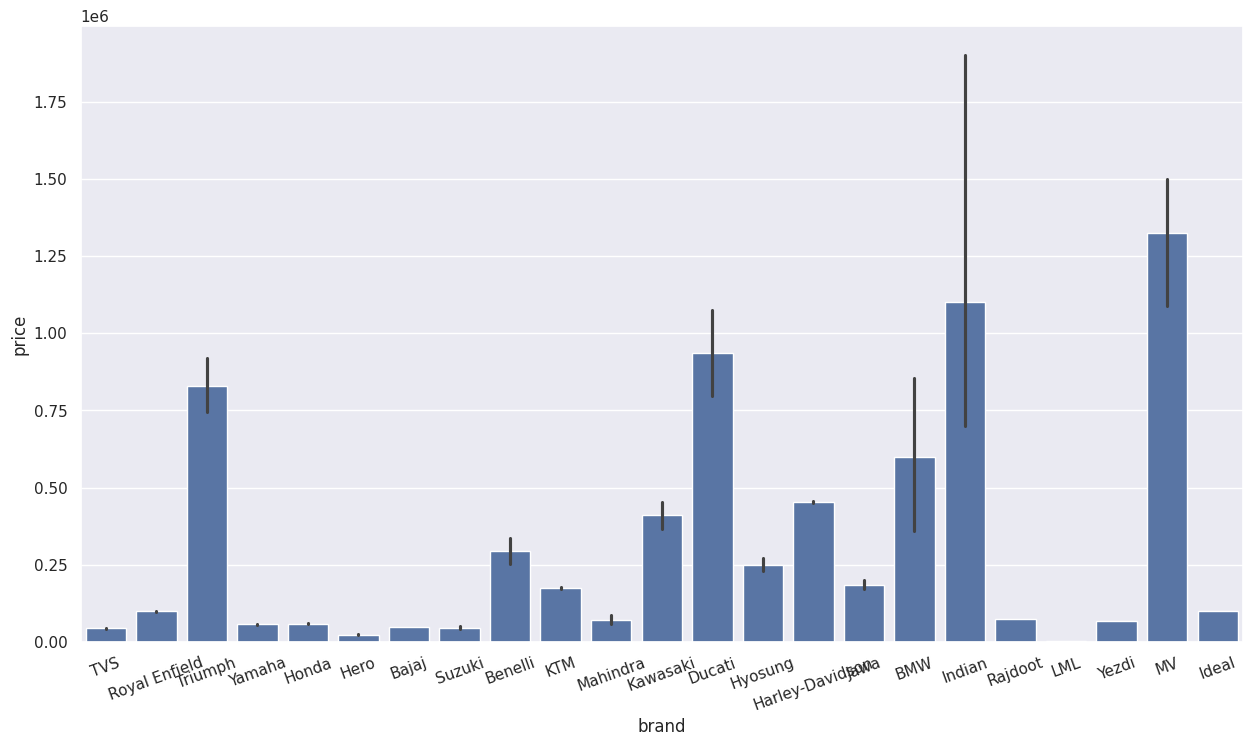

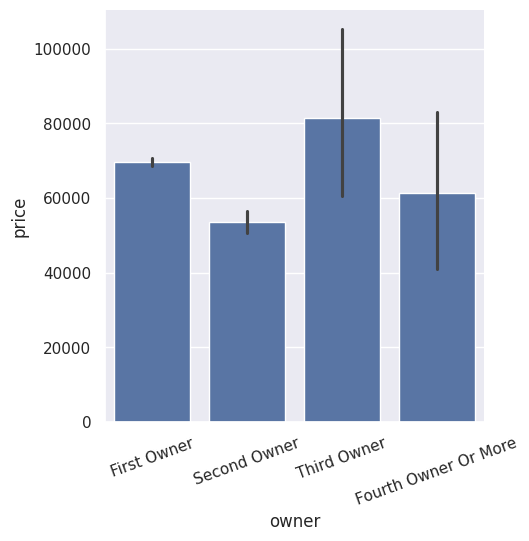

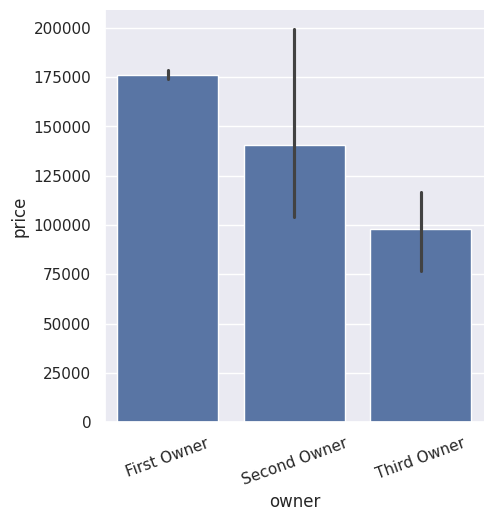

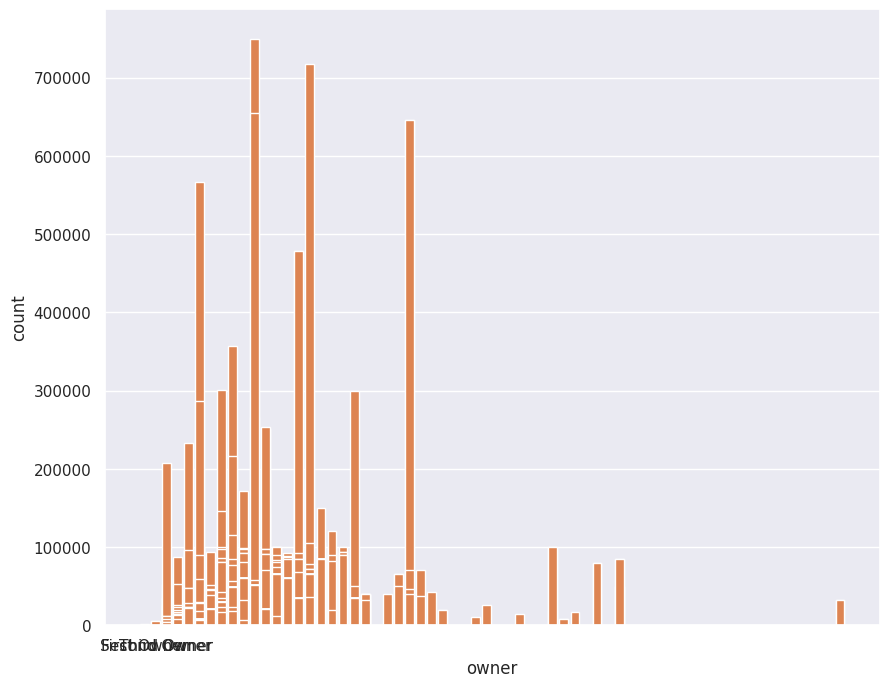

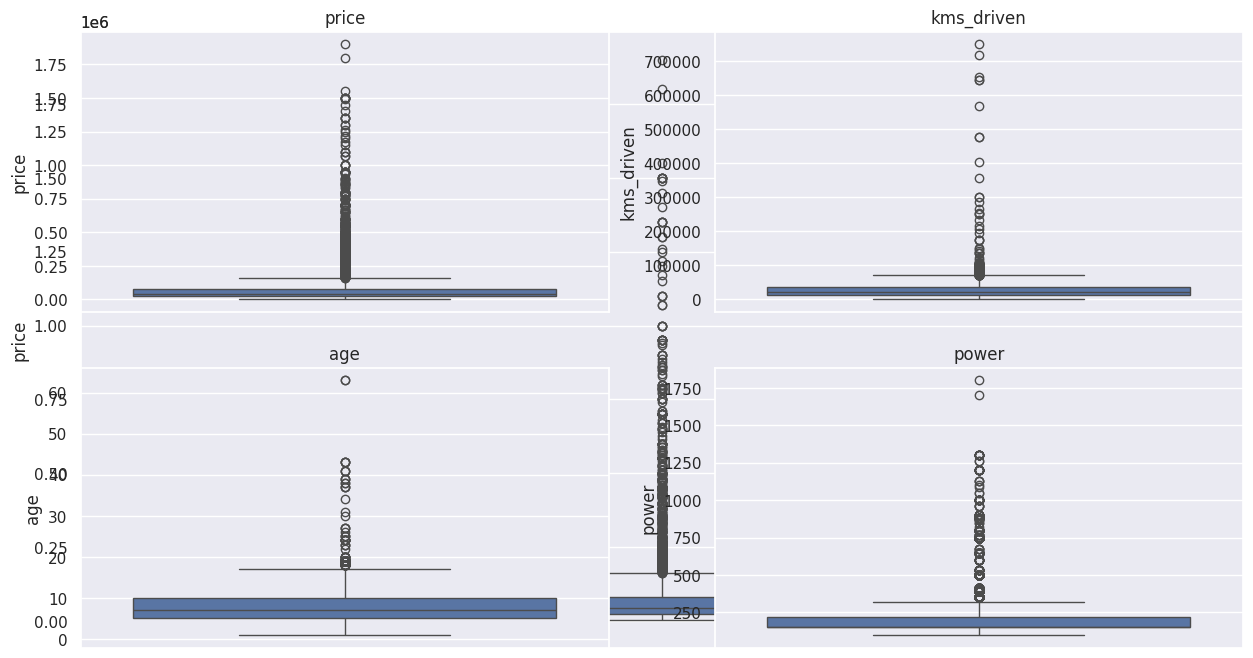

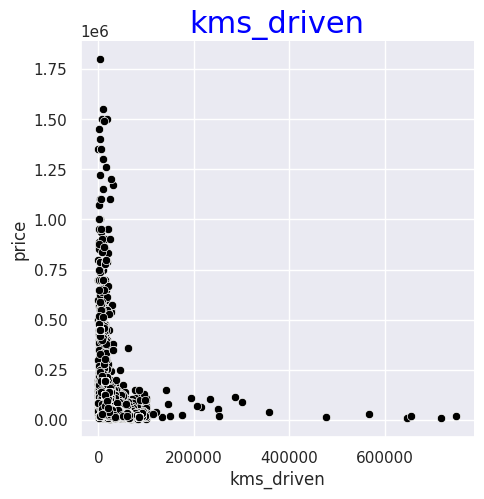

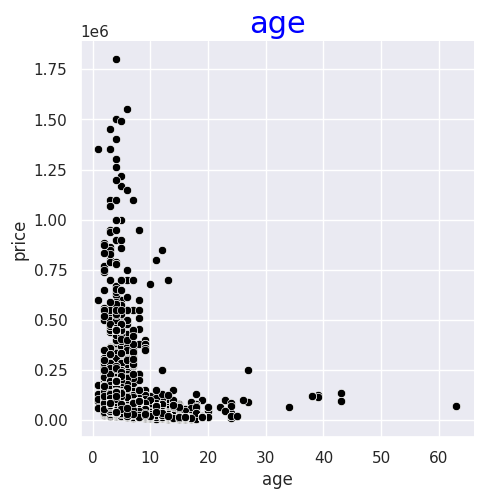

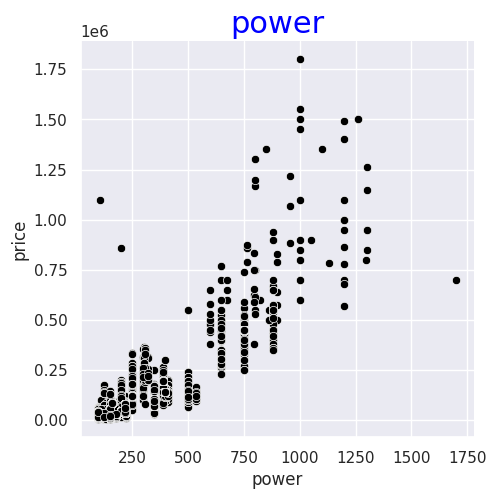

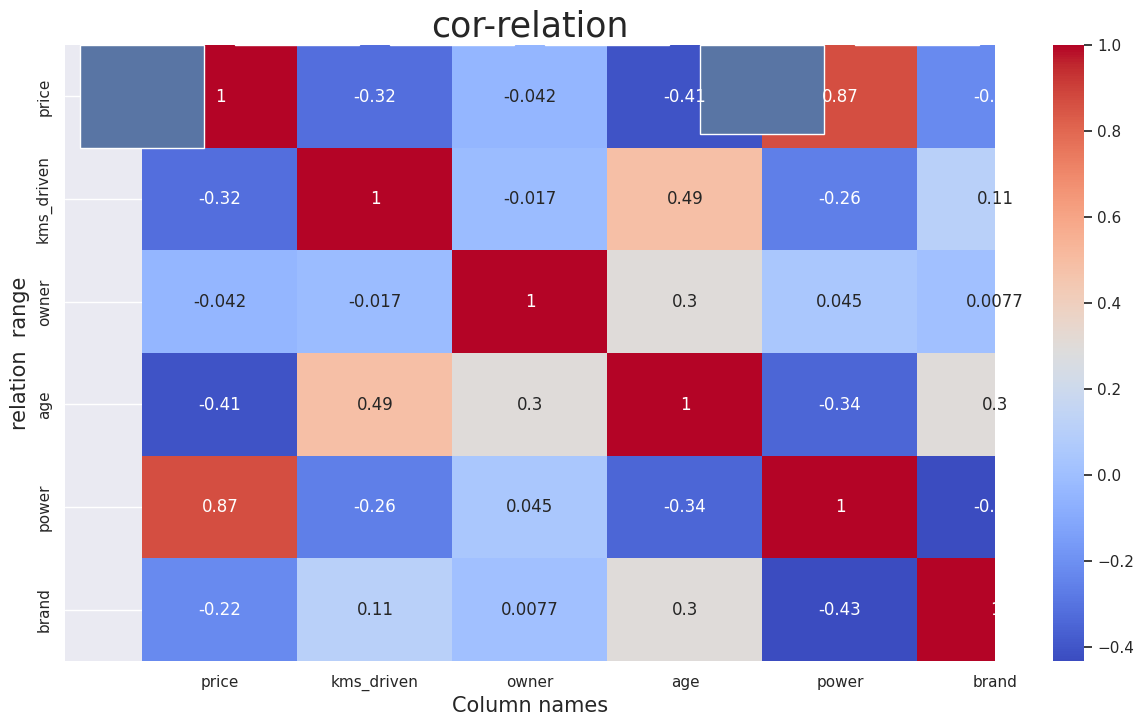

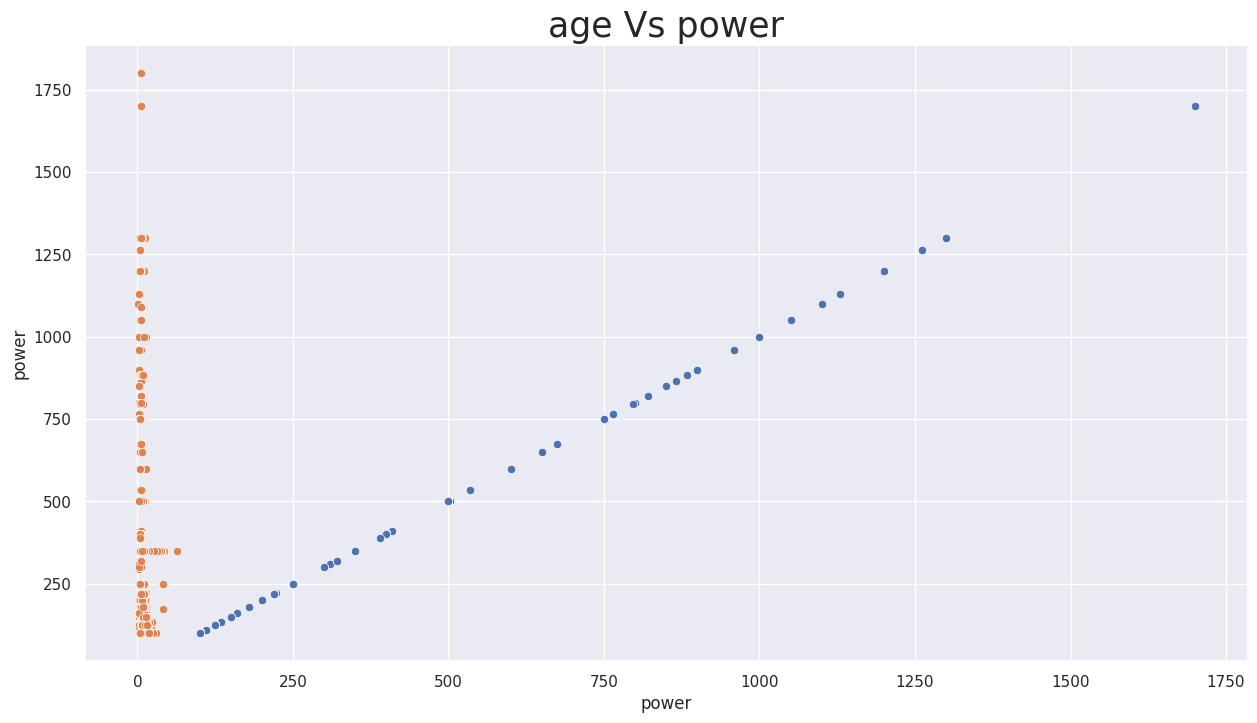

(31679, 7)
(17725, 7)
Training accuracy :-  0.9924333376149821
Testing accuracy :-  0.9584388513882656
Fitting 2 folds for each of 10 candidates, totalling 20 fits
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=20, min_samples_split=20, n_estimators=427; total time=   1.0s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=20, min_samples_split=20, n_estimators=427; total time=   1.1s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=15, min_samples_split=30, n_estimators=245; total time=   0.6s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=15, min_samples_split=30, n_estimators=245; total time=   0.6s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=20, min_samples_split=50, n_estimators=281; total time=   0.7s
[CV] END max_depth=3, max_features=sqrt, min_samples_leaf=20, min_samples_split=50, n_estimators=281; total time=   0.7s
[CV] END max_depth=3, max_features=auto, min_samples_leaf=15, min_samples_split=20, n_estimators=318; total ti

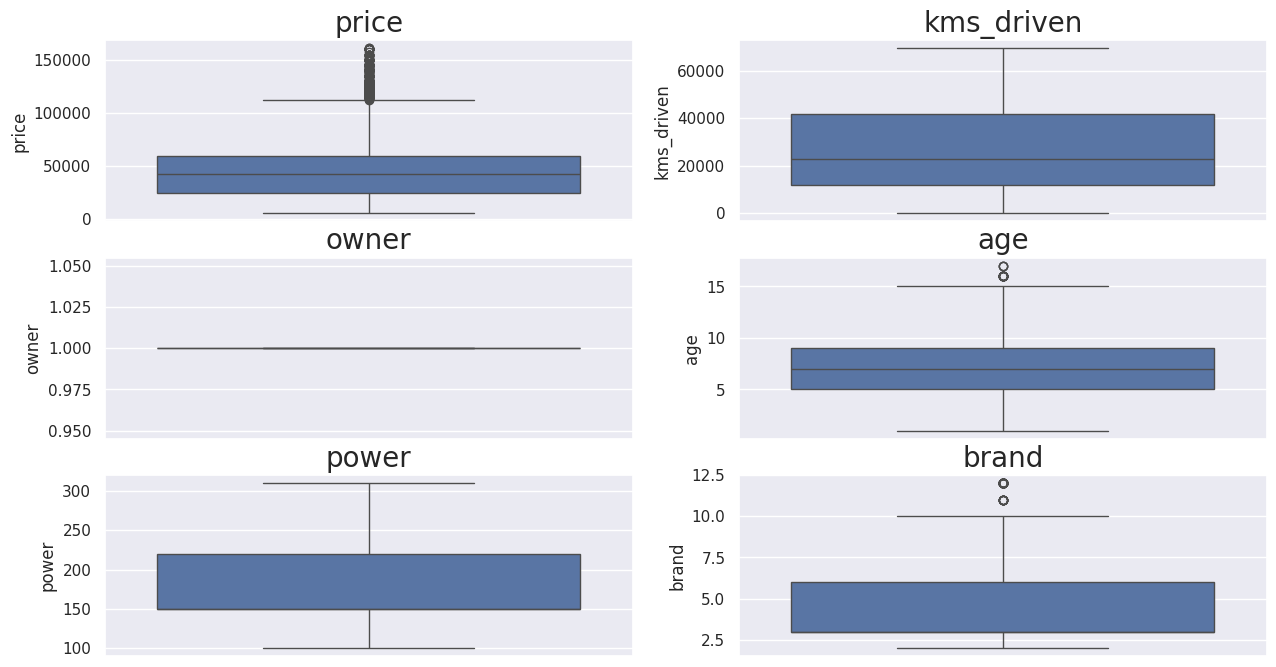

In [ ]:
# Old BIkes price prediction project 🛵
### importing library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import pickle
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('Used_Bikes.csv')
df.head()
df.shape
df.info()
df.describe()
df['brand'].value_counts()
df['owner'].value_counts()
### check the missing value
df.isnull().sum().sum()       # there is no missing value
df['brand'].nunique()         # total 23 brand
df['brand'].unique()
# all are unique brands available in my dataset
df['bike_name'].nunique()
# Total no. unique bikes available in my dataset
df[df['brand']=='Hero'].shape
# total Hero brand bike
## KTM bike analyses
ktm = df[df['brand']=='KTM']
ktm.head()
ktm.shape[0]          # total KTM bike
ktm['bike_name'].nunique()    # 10 unique KTM bikes
ktm['bike_name'].unique()
# all are ktm bike available in our dataset
print(f"maximum price of ktm bike :- {ktm['price'].max()}")
ktm['owner'].value_counts()
# availibility of ktm bike
# cd delux bike analysis
hero = df[df['brand']=='Hero']
hero.head()
print(f"Total no. of unique bike of hero :- {hero['bike_name'].nunique()}")
cd_delux = hero[hero['bike_name'].str.contains('CD')]
cd_delux.head()
#filtering data of cd delux bike of hero
print(f"Total no. of cd delux unique bik :- {cd_delux.shape[0]}" )          # 706 CD delux bike
print(f"minimum price of cd delux bike :- {cd_delux['price'].min()}")      # minimum price of cd delux bike
hero[hero['bike_name'].str.contains('CD')]['price'].max()         # maximum price of CD Delux
df['city'].value_counts().keys().shape[0]          # 443 city record available
### analyse the data with groupby properties
df.head(2)
grouped=df.groupby(by='city')       # grouped the data by city columns
grouped.get_group('Ahmedabad')
f"bikes available in Delhi :- {grouped.get_group('Delhi').shape[0]}"
grouped.get_group('Delhi')[['age']].head()       # get a particular column from the grouped data
grouped.get_group('Delhi')[['age']].max()        #maximum old bike in delhi
grouped.get_group('Delhi')[['age']].min()        #minimum old bike in delhi
df[(df['city']=='Delhi') & (df['age']==1)]         #[['bike_name','brand']]
grouped.get_group('Delhi')['brand'].value_counts().keys()         # all brand available in Delhi
grouped['owner'].value_counts()['Delhi']           # mostly first handed used bikes availabel in delhi
## divide the data based on the data types
df.dtypes
### Dividing Data  into 2 parts based on data type
catigorical_data = df.select_dtypes(include='O')
catigorical_data.head()
numerical_data = df.select_dtypes(exclude='O')
numerical_data.head()
numerical_data.describe()
catigorical_data.describe()
# to remove the "bike_name" feature
df=df.drop('bike_name',axis=1)
df.head(2)
## Data Visualization
sns.set(rc={'figure.figsize':(15,8)})
sns.barplot(x=df['brand'],y=df['price'])
plt.xticks(rotation=20)
plt.show()
sns.catplot(x='owner',y='price',kind='bar',data=df)
plt.xticks(rotation=20)
plt.show()
sns.catplot(x='owner',y='price',kind='bar',data=ktm)   # for ktm bike
plt.xticks(rotation=20)
plt.show()
plt.figure(figsize=(10,8))
sns.countplot(x='owner',data=df.query("brand=='KTM'"))
# sns.set(rc={'figure.figsize':(18,10)})
plt.bar(x=df['age'],height=df['kms_driven'])
plt.show()
df[(df['age']>=44)&(df['age']<=60)]      # there is no record in between this range
numerical_data.columns
sns.boxplot(df['price'])
for i , colum in enumerate(numerical_data.columns):
    plt.subplot(2,2,i+1)
    sns.boxplot(df[colum])
    plt.title(colum)

## data cleaning
df.dtypes
df['age']=df['age'].astype(int)
dic={'First Owner':1,'Second Owner':2,'Third Owner':3,'Fourth Owner Or More':4}

df['owner']=df['owner'].map(dic)
df['owner'].value_counts()
ser=df['city'].value_counts()
ser[ser>10].keys()
city_name=['Delhi', 'Bangalore', 'Mumbai', 'Hyderabad', 'Pune', 'Chennai',
       'Lucknow', 'Jaipur', 'Ghaziabad', 'Ahmedabad', 'Noida', 'Bhopal',
       'Gautam Buddha Nagar', 'Kanchipuram', 'Jodhpur', 'Karnal', 'Allahabad',
       'Rupnagar', 'Gurgaon', 'Godhara', 'Faridabad', 'Perumbavoor', 'Kadapa',
       'Ludhiana', 'Kolkata', 'Thane', 'Jhansi', 'Vadodara', 'Surat',
       'Jalandhar', 'Chandigarh', 'Rajkot', 'Indore', 'Dehradun', 'Patna',
       'Navi Mumbai', 'Nagpur', 'Coimbatore', 'Guwahati', 'Tiruvallur',
       'Bhubaneshwar', 'Howrah', 'Kanpur', 'Aurangabad', 'Cuttack',
       'Visakhapatnam', 'Alibag', 'Alipore', 'Nashik', 'Ranchi', 'Kalyan',
       'Rohtak', 'Udaipur', 'Gorakhpur', 'Agra', 'Kota', '24 Pargana',
       'Meerut', 'Gandhinagar', 'Ernakulam']
maxc_ten_bike = df[df['city'].isin(city_name)]
maxc_ten_bike.head()
# these are all city data that having at least 10 bikes
maxc_ten_bike['city'].value_counts().shape[0]              # total 60 city available in my data
# Filtering Data ...
bikes_name=df['brand'].value_counts()
most_available_bikes = bikes_name[bikes_name>10].keys()
greater_than_ten_bike = maxc_ten_bike[maxc_ten_bike['brand'].isin(most_available_bikes)]
greater_than_ten_bike.head()

# bike brand labeling
bike_encoding_dict={'Bajaj':3, 'Hero':16, 'Royal Enfield':1, 'Yamaha':5, 'Honda':6, 'Suzuki':7, 'TVS':8,
       'KTM':2, 'Harley-Davidson':4, 'Kawasaki':9, 'Hyosung':10, 'Benelli':11, 'Mahindra':12,
       'Triumph':13, 'Ducati':14, 'BMW':15}
greater_than_ten_bike['brand']=greater_than_ten_bike['brand'].map(bike_encoding_dict)
greater_than_ten_bike.head()
df2 = greater_than_ten_bike
df2[df2['brand']==12].head()
# TO check the correlation in between independent and dependent feature
sns.relplot(x='kms_driven',y='price',data=df2,color='black')            #,hue='age',
plt.title('kms_driven',fontdict={'fontsize':22,'color':'blue'})
plt.show()
sns.relplot(x='age',y='price',data=df2,color='black')
plt.title('age',fontdict={'fontsize':22,'color':'blue'})
plt.show()
# positive relation
sns.relplot(x='power',y='price',data=df2,color='black')            #,hue='age',
plt.title('power',fontdict={'fontsize':22,'color':'blue'})
plt.show()
sns.heatmap(df2.select_dtypes(exclude='O').corr(),annot=True,cmap='coolwarm')
# checking corelation
sns.barplot(x = df2.select_dtypes(exclude='O').corr()['price'].keys(),y=df2.select_dtypes(exclude='O').corr()['price'].values)
plt.title('cor-relation',size=25)
plt.xlabel('Column names',size=15)
plt.ylabel('relation  range',size=15)
plt.show()
# ploting the corelation
sns.scatterplot(x='power',y='power',data=df2)
# this is +1 relationship because, we plot relation in same columns
sns.scatterplot(x='age',y='power',data=df)
plt.title('age Vs power',size=25)
plt.show()
## to remove the outliers by IQR method
numerical_data = df2.select_dtypes(exclude='O')
categorical_data = df2.select_dtypes(include='O')

#Where:<br>
#Q1 is the 25th percentile,<br>
#Q3 is the 75th percentile,<br>
#IQR is the interquartile range
#( Q3−Q1 ), and 1.5 <br>
#1.5 is the multiplier that determines how far away from the quartiles the <br>bounds will be.
### formula to remove outliers from the dataset
#LL= Q1 - (1.5 * IQR)<br>
#UL= Q3 + (1.5 * IQR)<br>

# from kms_driven feature
lower_limit = dict()
uper_limit = dict()

for colum in numerical_data.columns:
    q1,q3=df2[colum].quantile([.25,.75])   # 1st and 3rd quartile
    IQR=q3-q1        # calculating interquatile range
    LL=q1-(1.5*IQR)    # lower range
    UL=q3+(1.5*IQR)
    lower_limit[colum]=LL
    uper_limit[colum]=UL

lower_limit
# lower limits for all columns
uper_limit
# upper limits for all columns
print(df2.shape)
temp = 0
for lower_upper_pairs in list(zip(uper_limit.items(),lower_limit.items())):
    df2 =   df2[(df2[lower_upper_pairs[0][0]] >= lower_upper_pairs[1][1])  & (df2[lower_upper_pairs[0][0]] <= lower_upper_pairs[0][1])]
print(df2.shape)
df2.head(2)
df2 = df2.drop('city',axis=1)
df2.head(2)
for plot_no , col in enumerate(df2.columns):
    plt.subplot(3,2,plot_no+1)
    sns.boxplot(df2[col])
    plt.title(col,size=20)

## Set the variable for ML model
x = df2.drop('price',axis=1)
y = df2[['price']]
x.head(2)
y.head(2)
# Splitting the data into train and test
from sklearn.model_selection import train_test_split
x_train  ,x_test,   y_train,  y_test =  train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,  x_test.shape,   y_train.shape,   y_test.shape
x_train
y_train
from sklearn.ensemble import  RandomForestRegressor
rdf = RandomForestRegressor()
rdf.fit(x_train,y_train)
print("Training accuracy :- ",rdf.score(x_train,y_train))
print("Testing accuracy :- ",rdf.score(x_test,y_test))

# HYPER PARAMETER TUNING
#This is for research purpose, because yet now we got it good accuracy
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
rdf2 = RandomForestRegressor()
# Defining Parameters
n_estimators = [int(x) for x in np.linspace(start=100,stop=500,num=12)]
max_features = ['auto','sqrt']
max_depth = [int(x) for x in np.linspace(start=5,stop=3,num=6)]
min_samples_split = [20,30,50]
min_samples_leaf = [15,10,20]
# param grid
random_grid={'n_estimators':n_estimators,
            'max_features':max_features,
            'max_depth':max_depth,
            'min_samples_split':min_samples_split,
            'min_samples_leaf':min_samples_leaf}
rdm_rand_forest = RandomizedSearchCV(estimator=rdf2,param_distributions=random_grid,n_iter=10,cv=2,verbose=2,scoring='neg_mean_squared_error')
rdm_rand_forest.fit(x_train,y_train)
rdm_rand_forest.best_params_
best_estimator = rdm_rand_forest.best_estimator_
print("Training accuracy :- ",best_estimator.score(x_train,y_train))
print("Testing accuracy :- ",best_estimator.score(x_test,y_test))
# now THe accuracy is decreased 💔 our previos model is good
### Save th3 model
import joblib
joblib.dump(rdf,'updated_model.lb')
loaded_model = joblib.load('updated_model.lb')
### Prediction
pred = rdf.predict(x_test)
compare = y_test
compare['prediction'] = pred
compare.columns = ['actual','prediction']
compare.iloc[0:20]
print(rdf.score(x_train,y_train))
print(rdf.score(x_test,y_test['actual']))

#THANK YOU

Text Recognizer

In [ ]:
#CODE TO FETCH THE TEXT FROM IMAGE BUT BEFORE IT DOWNLOAD THE INSTALLER GIVEV ABOVE LINK

#!pip install pytesseract
#!pip install tesseract

#!apt-get update
#!apt-get install tesseract-ocr -y

#!pip install easyocr

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 

In [ ]:
from PIL import Image
import pytesseract as tess

tess.pytesseract.tesseract_cmd = r'/usr/bin/tesseract'

# Load the image from file
img = Image.open('img3.jpeg')

# Use pytesseract to extract text
text = tess.image_to_string(img)

# Print the extracted text
print("--- Extracted Text ---")
print(text)

--- Extracted Text ---
The best
preparation
for tomorrow
is doing your
best today.



In [ ]:
import easyocr
from PIL import Image
#first time it will download the models, for detection
reader = easyocr.Reader(['hi', 'en'])

result = reader.readtext('img2.jpeg')
result
# text with bounding box cordinates and confidence score

# to get actuall information, that you want
result = reader.readtext('img2.jpeg',detail=0)
print(result)
print(" ".join(result))

## pillow object
img = Image.open('img3.jpeg')
img

# passed img object to ocr
reader.readtext(img,detail=0)

## you can pass the data as a byte
with open('img2.jpeg','rb') as file :
    image_data = file.read()

    result = reader.readtext(image_data,detail=0)
    print(" ".join(result))

['YOU ARE', 'STRONGER', 'THAN YOU', 'THINK']
YOU ARE STRONGER THAN YOU THINK
YOU ARE STRONGER THAN YOU THINK


student data

In [ ]:
# Lasso Regression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

url = "https://raw.githubusercontent.com/rajendra0968jangid/ml-project-1/main/student_performance.csv"
df = pd.read_csv(url)

X = df[['Study_Hours','Attendance','Internal_Marks','Assignment_Marks','Practical_Marks']]

Y = df[['Final_Score']]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

model = Lasso(alpha=0.1)
model.fit(X_train,X_train)

prediction = model.predict(X_test)

print("Lasso Regression Prediction:")
print(prediction)

Lasso Regression Prediction:
[[ 9.86238145 96.99230079 94.98397402 96.02161793 97.13146937]
 [ 2.81226762 74.91112637 60.03026102 64.91863296 62.71163029]]


In [ ]:
# Elastic Net Regression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import ElasticNet

url = "https://raw.githubusercontent.com/rajendra0968jangid/ml-project-1/main/student_performance.csv"
df = pd.read_csv(url)

X = df[['Study_Hours','Attendance','Internal_Marks','Assignment_Marks','Practical_Marks']]

Y = df[['Final_Score']]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(X_train,Y_train)

prediction = model.predict(X_test)

print("Elastic Net Regression Prediction")
print(prediction)

Elastic Net Regression Prediction
[97.55626177 62.10379729]


world population project


In [ ]:
import pandas as pd
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import os

# Load dataset
df = pd.read_csv("world_population.csv")

# Store transformed rows
data = []

years = [1970, 1980, 1990, 2000, 2010, 2015, 2020, 2022]

# Convert wide data into long format
for _, row in df.iterrows():
    country = row['Country/Territory']
    for year in years:
        population = row[f'{year} Population']
        data.append([country, year, population])

# Create processed dataframe
processed_df = pd.DataFrame(
    data,
    columns=['Country', 'Year', 'Population']
)

# Save processed dataframe
joblib.dump(processed_df, "processed_data.pkl")

print("Processed data saved successfully")

# Train Polynomial Regression models for each country
print("\nTraining Polynomial Regression models for each country...")

countries = processed_df['Country'].unique()
models = {}

for country in countries:
    country_data = processed_df[processed_df['Country'] == country]

    X = country_data[['Year']].values
    y = country_data['Population'].values

    # Train Polynomial Regression model (Degree 2 usually works well for population without overfitting into extreme curves)
    model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
    model.fit(X, y)

    models[country] = model
    print(f"Done: {country}")

# Save all models
joblib.dump(models, "population_models.pkl")
print("\nAll models saved successfully!")

Processed data saved successfully

Training Polynomial Regression models for each country...
Done: Afghanistan
Done: Albania
Done: Algeria
Done: American Samoa
Done: Andorra
Done: Angola
Done: Anguilla
Done: Antigua and Barbuda
Done: Argentina
Done: Armenia
Done: Aruba
Done: Australia
Done: Austria
Done: Azerbaijan
Done: Bahamas
Done: Bahrain
Done: Bangladesh
Done: Barbados
Done: Belarus
Done: Belgium
Done: Belize
Done: Benin
Done: Bermuda
Done: Bhutan
Done: Bolivia
Done: Bosnia and Herzegovina
Done: Botswana
Done: Brazil
Done: British Virgin Islands
Done: Brunei
Done: Bulgaria
Done: Burkina Faso
Done: Burundi
Done: Cambodia
Done: Cameroon
Done: Canada
Done: Cape Verde
Done: Cayman Islands
Done: Central African Republic
Done: Chad
Done: Chile
Done: China
Done: Colombia
Done: Comoros
Done: Cook Islands
Done: Costa Rica
Done: Croatia
Done: Cuba
Done: Curacao
Done: Cyprus
Done: Czech Republic
Done: Denmark
Done: Djibouti
Done: Dominica
Done: Dominican Republic
Done: DR Congo
Done: Ecuador

Stock Prize Prediction

/tmp/ipykernel_4483/2037132931.py:23: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2015-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   2516 non-null   float64
 1   (High, GOOG)    2516 non-null   float64
 2   (Low, GOOG)     2516 non-null   float64
 3   (Open, GOOG)    2516 non-null   float64
 4   (Volume, GOOG)  2516 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


/tmp/ipykernel_4483/2037132931.py:65: PerformanceWarning:

dropping on a non-lexsorted multi-index without a level parameter may impact performance.



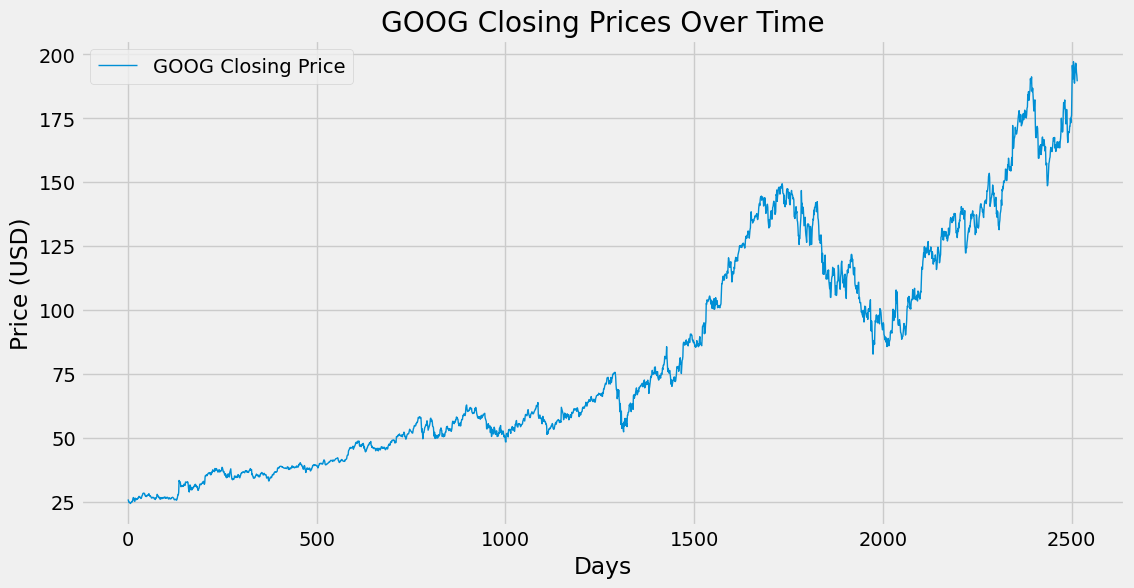

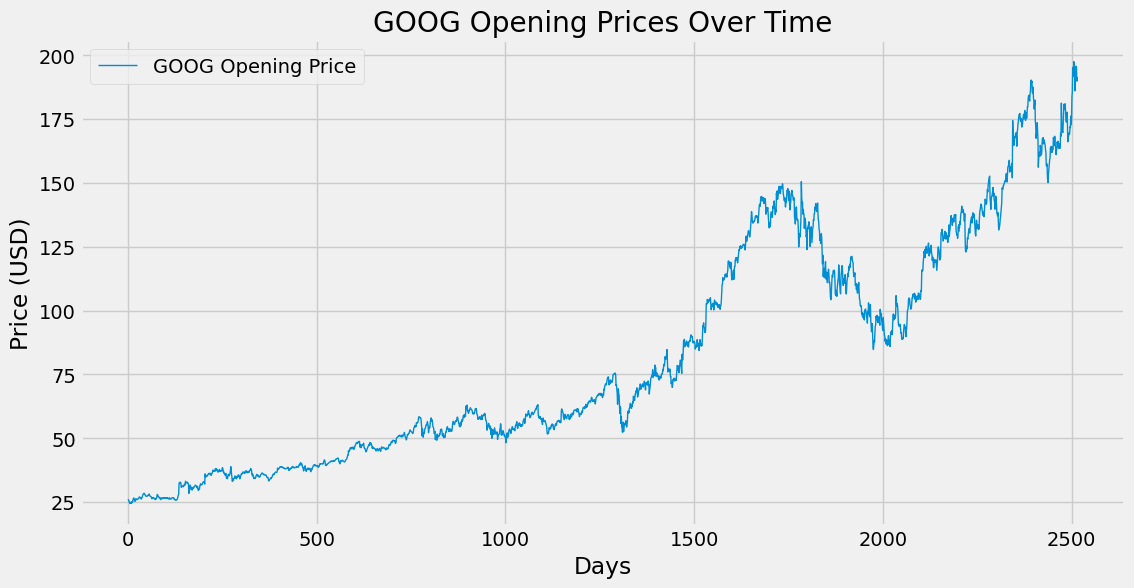

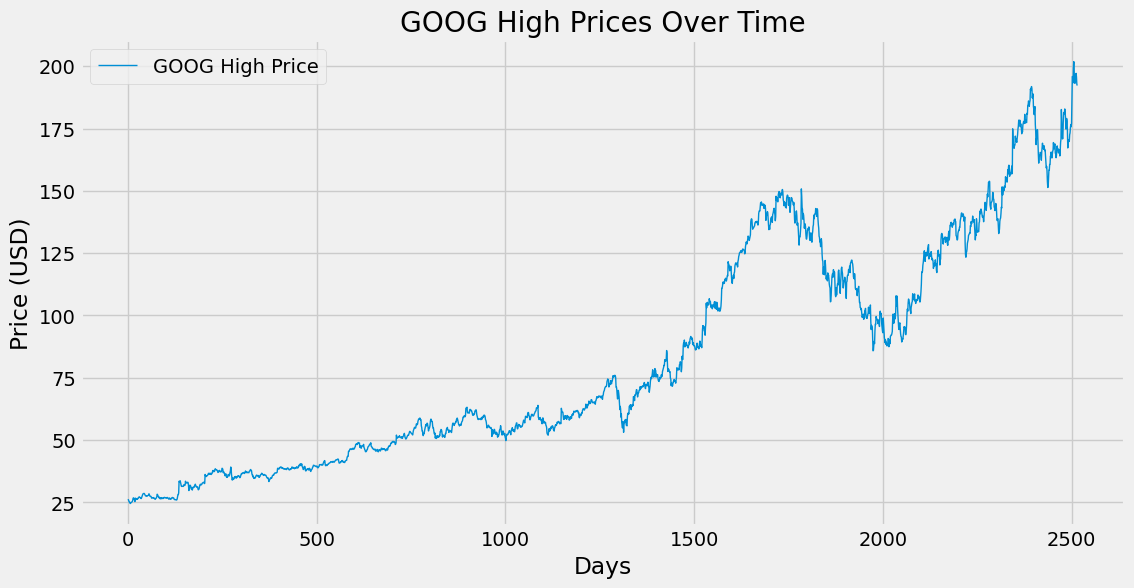

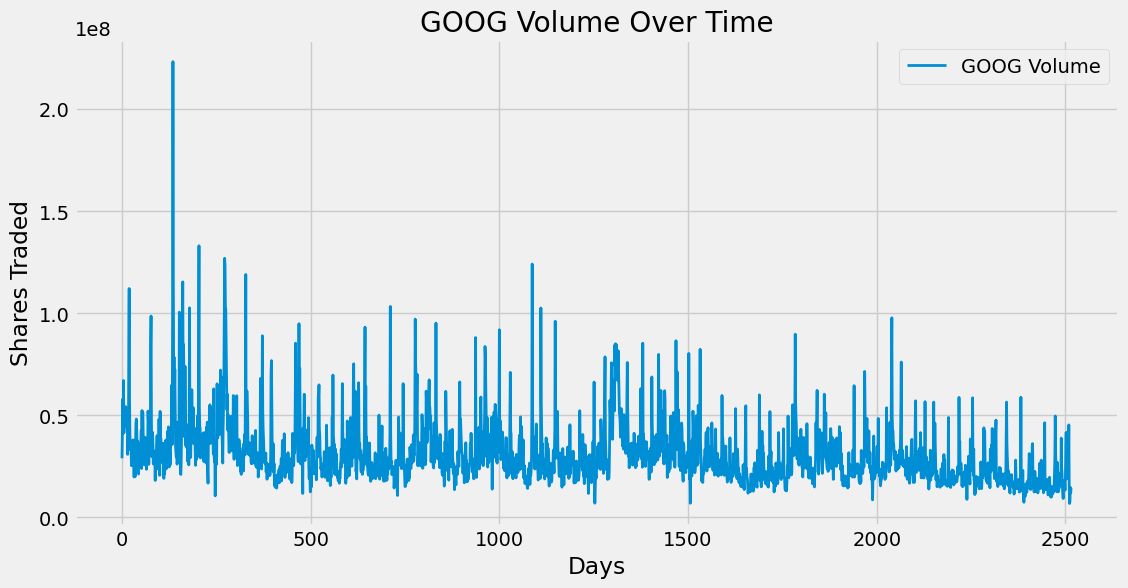

5-day average for elements 3-7: 50.0
5-day rolling mean:
   Value
0    NaN
1    NaN
2    NaN
3    NaN
4   30.0
5   40.0
6   50.0
7   60.0
8   70.0
100-day moving average:
Ticker  GOOG
0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
5        NaN
6        NaN
7        NaN
8        NaN
9        NaN
200-day moving average:
Ticker  GOOG
0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
5        NaN
6        NaN
7        NaN
8        NaN
9        NaN


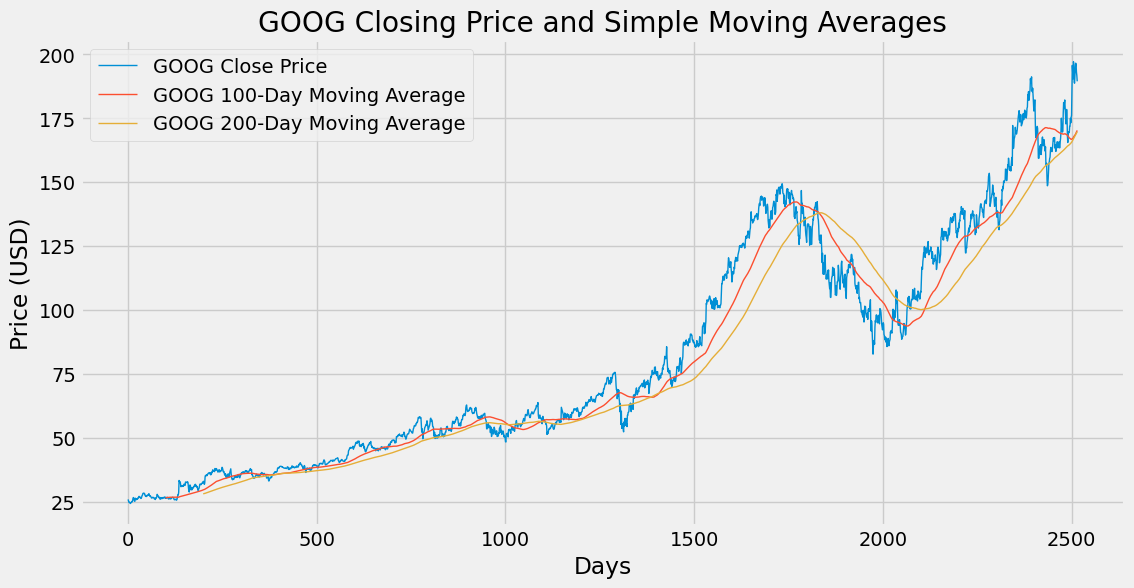

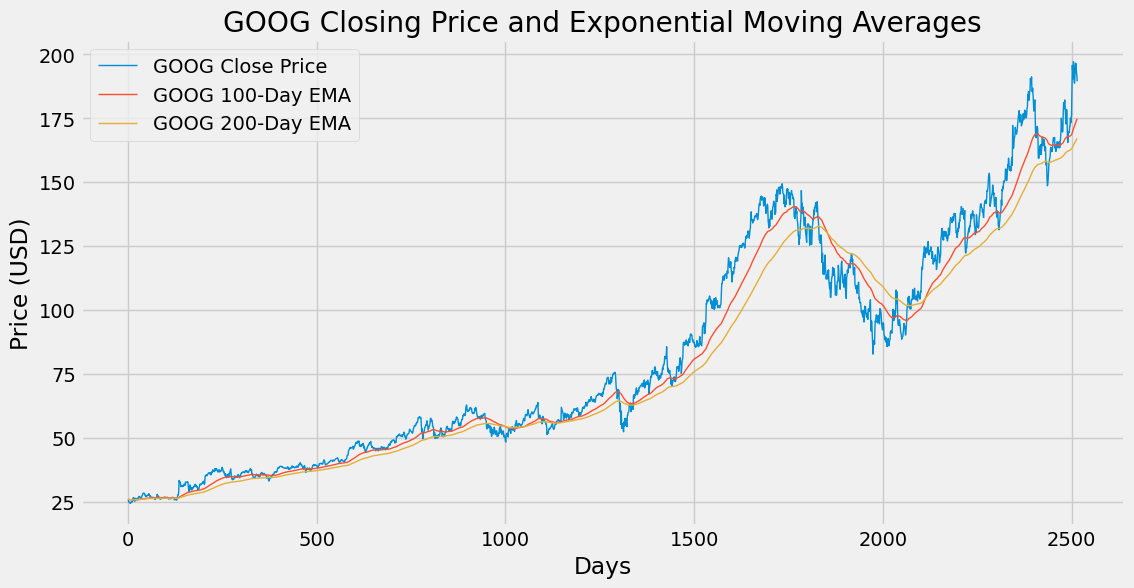

Training data shape: (1761, 1)
Testing data shape: (755, 1)
Scaled training data shape: (1761, 1)
x_train shape (samples, time steps, features): (1661, 100, 1)
y_train shape: (1661,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_22 (LSTM)                  │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_23 (LSTM)                  │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step - loss: 0.0329
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step - loss: 0.0060
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 274ms/step - loss: 0.0049
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 259ms/step - loss: 0.0048
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 289ms/step - loss: 0.0044
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 19s 260ms/step - loss: 0.0041
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - loss: 0.0042
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 259ms/step - loss: 0.0032
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 21s 260ms/step - loss: 0.0036
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step - loss: 0.0033
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 258ms/step - loss: 0.0034
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 260ms/step - loss: 0.0028
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 259ms/step - loss: 0.0028
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 259ms/step - loss: 0.0030
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 

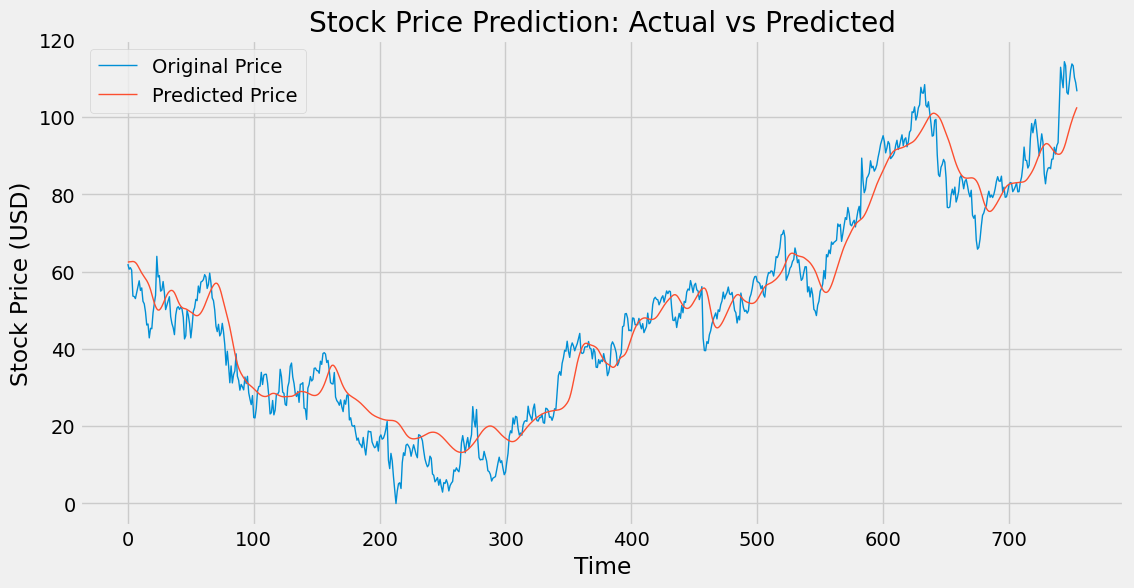

Model saved as stock_dl_model.h5


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

# Set the plot style for better aesthetics
plt.style.use('fivethirtyeight')

# This magic command is for Jupyter notebooks to display plots inline
%matplotlib inline

import yfinance as yf
import datetime as dt

# Define the stock ticker symbol
stock = "GOOG"

# Set the date range for the data
start = dt.datetime(2015, 1, 1)
end = dt.datetime(2025, 1, 1)

# Download the historical stock data from Yahoo Finance
df = yf.download(stock, start, end)

# Display the first few rows to check the downloaded data
df.head()

# Show the last 5 rows of the dataset to see the most recent data
df.tail()

# Show concise summary including data types, non-null counts, memory usage
df.info()

# Display the number of rows and columns (shape of the dataframe)
df.shape

# Check for missing values in each column
df.isnull().sum()

# Get statistical summary of numerical features (count, mean, std, min, 25%, 50%, 75%, max)
df.describe()

# Reset the index so the date becomes a column instead of the index (important for CSV)
df = df.reset_index()
df.columns

# Save the DataFrame to a CSV file
df.to_csv("Google_stock_data.csv", index=False)
# Read the saved CSV back into a new DataFrame
data01 = pd.read_csv("Google_stock_data.csv")
# Display the first few rows of the reloaded data to verify
data01.head()

import plotly.graph_objects as go

# Candlestick Chart for stock price visualization

fig = go.Figure(data=[go.Candlestick(x = data01['Date'], open = data01['Open'],
                                    high = data01['High'],
                                    low = data01['Low'],
                                    close = data01['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()
# Drop the Date column from df (already present as a column in data01)
df = df.drop(['Date'], axis=1)

# Show the first few rows to confirm
df.head()

# Plot Closing Price over time
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label=f'{stock} Closing Price', linewidth=1)
plt.title(f'{stock} Closing Prices Over Time')
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

# Plot Opening Price over time
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label=f'{stock} Opening Price', linewidth=1)
plt.title(f'{stock} Opening Prices Over Time')
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


# Plot High Price over time
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label=f'{stock} High Price', linewidth=1)
plt.title(f'{stock} High Prices Over Time')
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


# Plot Volume over time
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label=f'{stock} Volume', linewidth=2)
plt.title(f'{stock} Volume Over Time')
plt.xlabel("Days")
plt.ylabel("Shares Traded")
plt.legend()
plt.show()

# Example: Calculate the moving average for the last 5 days in a small dataset
temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90]

# Calculate the mean of 5 elements (from index 2 to 6)
print("5-day average for elements 3-7:", sum(temp_data[2:7])/5)

# Create a DataFrame for rolling calculations
df01 = pd.DataFrame(temp_data, columns=['Value'])
# Calculate the rolling mean with window size 5
print("5-day rolling mean:")
print(df01.rolling(5).mean())

# Calculate the 100-day moving average for the closing price
ma100 = df['Close'].rolling(100).mean()
# Display a few values of the 100-day moving average
print("100-day moving average:")
print(ma100.head(10))

# Calculate the 200-day moving average for the closing price
ma200 = df['Close'].rolling(200).mean()
# Display a few values of the 200-day moving average
print("200-day moving average:")
print(ma200.head(10))

plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label=f'{stock} Close Price', linewidth=1)
plt.plot(ma100, label=f'{stock} 100-Day Moving Average', linewidth=1)
plt.plot(ma200, label=f'{stock} 200-Day Moving Average', linewidth=1)
plt.title(f"{stock} Closing Price and Simple Moving Averages")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()


# Calculate Exponential Moving Averages
ema100 = df['Close'].ewm(span=100, adjust=False).mean()
ema200 = df['Close'].ewm(span=200, adjust=False).mean()
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label=f'{stock} Close Price', linewidth=1)
plt.plot(ema100, label=f'{stock} 100-Day EMA', linewidth=1)
plt.plot(ema200, label=f'{stock} 200-Day EMA', linewidth=1)
plt.title(f"{stock} Closing Price and Exponential Moving Averages")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

from sklearn.preprocessing import MinMaxScaler

# Split the closing price data into training (first 70%) and testing (last 30%) sets
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):])
print("Training data shape:", data_training.shape)
print("Testing data shape:", data_testing.shape)

# Scale the training data to the range [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
data_training_array = scaler.fit_transform(data_training)
print("Scaled training data shape:", data_training_array.shape)

data_training_array.shape[0]

# Prepare the training sequences
x_train = []
y_train = []

# For each entry, use the previous 100 days' closing prices as input (x), and the next day's price as output (y)
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
print("x_train shape (samples, time steps, features):", x_train.shape)
print("y_train shape:", y_train.shape)

# Model Building
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential
# Initialize the model
model = Sequential()

# Add LSTM and Dropout layers
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(units=1))

# Model summary
model.summary()


# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(x_train, y_train, epochs=50)

# Get the last 100 days from training and concatenate with testing data
past_100_days = data_training.tail(100)
# Use pd.concat() instead of .append() to combine the dataframes
final_df = pd.concat([past_100_days, data_testing], ignore_index = True)
final_df.head()

# Prepare test input
input_data = scaler.fit_transform(final_df)
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)
print("Shape of x_test:", x_test.shape)

# Predict prices
y_predicted = model.predict(x_test)
print("Shape of predictions:", y_predicted.shape)

# Get the scaler's scale parameter for reverse transformation
scaler_scale = scaler.scale_
# Adjust the scale factor (ensure this matches your scaler settings)
scaler_factor = 1 / scaler_scale[0]
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Original Price', linewidth=1)
plt.plot(y_predicted, label='Predicted Price', linewidth=1)
plt.title('Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()

model.save('stock_dl_model.h5')
print("Model saved as stock_dl_model.h5")



Covid - 19

                                                   ID        Accession  \
0   hCoV-19/Colombia/AMA-INS-LET-2-013/2021|EPI_IS...  EPI_ISL_1820959   
1        hCoV-19/Colombia/ANT-CWOHC-VG-SEC00108D/2021  EPI_ISL_1824702   
2        hCoV-19/Colombia/ANT-CWOHC-VG-SEC00109E/2021  EPI_ISL_1824703   
3        hCoV-19/Colombia/ANT-CWOHC-VG-SEC00167K/2021  EPI_ISL_1824706   
4        hCoV-19/Colombia/ANT-CWOHC-VG-SEC00189G/2021  EPI_ISL_1824711   
..                                                ...              ...   
84  hCoV-19/USA/MI-UM-10039251404/2021|EPI_ISL_175...  EPI_ISL_1753673   
85  hCoV-19/USA/NJ-CDC-ASC210006835/2021|EPI_ISL_1...  EPI_ISL_1562674   
86  hCoV-19/USA/NY-PRL-2021_03_24_00P15/2021|EPI_I...  EPI_ISL_1385573   
87  hCoV-19/USA/NY-PRL-2021_0405_00N23/2021|EPI_IS...  EPI_ISL_1542954   
88  hCoV-19/USA/NY-PRL-2021_0409_00G23/2021|EPI_IS...  EPI_ISL_1543900   

   Collection_date  Lineage Clade  LocationCountry   Gender      Age   Status  \
0       12/03/2021  B.1.621   

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:568: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


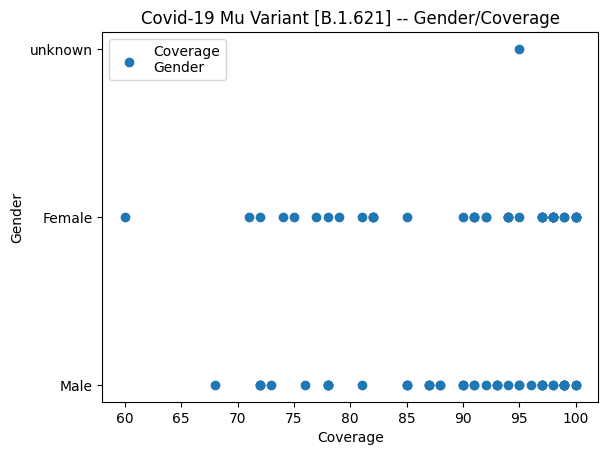

In [29]:

#libraries of the loading
from sklearn.ensemble import *
from sklearn.model_selection import *
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import *

#datasets loading...
mu_variant_data = pd.read_csv('mu-variant-data.csv')
print(mu_variant_data)
#change function..
def number_gender_change(x):
    if x == 'Male':
        return 0
    elif x == 'Female':
        return 1
    else:
        return 2

#change of the str to int.
mu_variant_data['Gender_Change'] = mu_variant_data['Gender'].apply(number_gender_change)

#creating of fetures
coverage_X = mu_variant_data.loc[:,['S:N501Y','S:E484K','S:R346K','S:P681H','Coverage']].values

#creating of class,target or label :)
gender_y = mu_variant_data.loc[:,['Gender_Change']].values

#fetaures print
#print(gender_y)

#try :)

#                                 *******CLASSIFICATION IS THE MU VARIANT*******
# we create the Train and Test datasets.. (parameters of the suitable)
coverage_X_train, coverage_X_test, gender_y_train, gender_y_test = train_test_split(coverage_X,
                                                                                    gender_y,
                                                                                    test_size=0.22,
                                                                                    stratify=None,
                                                                                    shuffle=True,
                                                                                    random_state=64)

# we create of the our model 8 Classifier)
model_mu_variant = BaggingClassifier(
                                     random_state=46,
                                     n_estimators=2,
                                     bootstrap=True,
                                     max_features=1.0,
                                     n_jobs=-1,
                                     warm_start=False)

# model is fitting with Train datasets.
model_mu_variant.fit(coverage_X_train, gender_y_train)

# Creating the Prediction equation
prediction = model_mu_variant.predict(coverage_X_test)

# Creating of Accuracy score, F1 Score, Recall Score, Precision Score and Confusion Matrix :)
print(f"Accuracy score: {accuracy_score(gender_y_test, prediction)}")
print(f"F1 score: {f1_score(gender_y_test, prediction)}")
print(f"Recall score: {recall_score(gender_y_test, prediction)}")
print(f"Precision score: {precision_score(gender_y_test, prediction)}")
# print(f"Confusion Matrix: {confusion_matrix(gender_y_test, prediction)}")

    #                                 *******PREDICTION IS THE MU VARIANT*******
X_train, X_test, y_train, y_test = train_test_split(coverage_X,
                                                    gender_y,
                                                    test_size=0.05,
                                                    stratify=None,
                                                    shuffle=True,
                                                    random_state=265)

# creating of our predicting model
model_mu_variant_predict = BaggingRegressor(
                                            random_state=149,
                                            n_estimators=1,
                                            bootstrap=True,
                                            max_features=1.0,
                                            n_jobs=-1,
                                            warm_start=True, bootstrap_features=True)

# our model is fitting..
model_mu_variant_predict.fit(X_train, y_train)

# our model is predicting..
a = model_mu_variant_predict.predict(X_test)

predi = model_mu_variant_predict.predict([[1, 1, 0, 1, 2]])

for i in predi:
    if i == [1.]:
        print("Congrats! Prediction Gender is the Female!")
    elif i == [0.]:
        print("Congrats! Prediction Gender is the Male!")
    else:
        print("Sorry! Prediction Gender is the Unknown!")

# our prediction software is the accuracy score :)
print(f"Prediction Model Accuracy Score: {r2_score(y_test, a)} ")


feature_names = mu_variant_data.loc[:,['S:N501Y','S:E484K','S:R346K','S:P681H','Coverage']].columns

from sklearn.tree import *

def save_decision_trees_as_dot(model_mu_variant, iteration, feature_name):
    #file_name = open("emirhan_mu_variant_classification" + str(iteration) + ".dot", 'w')
    dot_data = export_graphviz(
        model_mu_variant,
        #out_file=file_name,
        feature_names=feature_name,
        class_names=['Male','Female','Unknown'],
        rounded=True,
        proportion=False,
        precision=2,
        filled=True, )
    #file_name.close()
    print("Classification {} saved as dot file".format(iteration + 1))


# Save of the .dot loop..
#for i in range(len(model_mu_variant.estimators_)):
    #save_decision_trees_as_dot(model_mu_variant.estimators_[i], i, feature_names)
    #print(i)


plt.scatter(mu_variant_data['Coverage'],mu_variant_data['Gender'])
plt.legend(["Coverage\nGender"])
plt.xlabel("Coverage")
plt.ylabel("Gender")
plt.title("Covid-19 Mu Variant [B.1.621] -- Gender/Coverage")
plt.show()